In [11]:
import cv2
from matplotlib import pyplot
import numpy
from scipy.fftpack import dct
from scipy.fftpack import idct
import struct
import zlib
import os
from PIL import Image

# Zadanie 1

In [10]:
width = 100
height = 100

#
# PPM file header
#
ppm_ascii_header = f'P3\n{width} {height}\n255\n'
ppm_binary_header = f'P6\n{width} {height}\n255\n'

#
# Image data
#
image = numpy.full((height, width, 3), [255, 0, 0], dtype=numpy.uint8)

#
# Save the PPM image as an ASCII file
#
with open('lab4-ascii.ppm', 'w') as fh:
    fh.write(ppm_ascii_header)
    image.tofile(fh, sep=' ')
    fh.write('\n')

#
# Save the PPM image as a binary file
#
with open('lab4-binary.ppm', 'wb') as fh:
    fh.write(bytearray(ppm_binary_header, 'ascii'))
    image.tofile(fh)

size_ascii = os.path.getsize('lab4-ascii.ppm')
size_binary = os.path.getsize('lab4-binary.ppm')

print(f"Rozmiar pliku ASCII (P3): {size_ascii} bajtów")
print(f"Rozmiar pliku binarnego (P6): {size_binary} bajtów")

Rozmiar pliku ASCII (P3): 80019 bajtów
Rozmiar pliku binarnego (P6): 30015 bajtów


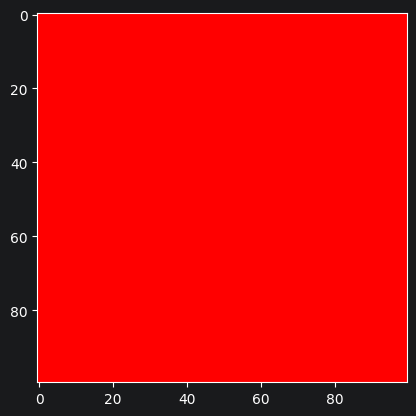

In [7]:
#
# Display image
#
image_from_file = cv2.imread('lab4-ascii.ppm')
pyplot.imshow(cv2.cvtColor(image_from_file, cv2.COLOR_BGR2RGB))

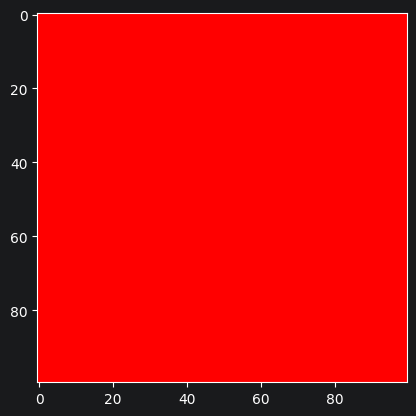

In [8]:
#
# Display image
#
image_from_file = cv2.imread('lab4-binary.ppm')
pyplot.imshow(cv2.cvtColor(image_from_file, cv2.COLOR_BGR2RGB))

# Zadanie 2

In [1]:
import numpy as np

height = 100
segment_width = 256

width = 7 * segment_width

vals = np.arange(256, dtype=np.uint8)
inv_vals = np.arange(255, -1, -1, dtype=np.uint8)
full = np.full(256, 255, dtype=np.uint8)
zero = np.zeros(256, dtype=np.uint8)
gradient_row = np.zeros((width, 3), dtype=np.uint8)

gradient_row[0:256, 0] = zero
gradient_row[0:256, 1] = zero
gradient_row[0:256, 2] = vals

gradient_row[256:512, 0] = zero
gradient_row[256:512, 1] = vals
gradient_row[256:512, 2] = full

gradient_row[512:768, 0] = zero
gradient_row[512:768, 1] = full
gradient_row[512:768, 2] = inv_vals

gradient_row[768:1024, 0] = vals
gradient_row[768:1024, 1] = full
gradient_row[768:1024, 2] = zero

gradient_row[1024:1280, 0] = full
gradient_row[1024:1280, 1] = inv_vals
gradient_row[1024:1280, 2] = zero

gradient_row[1280:1536, 0] = full
gradient_row[1280:1536, 1] = zero
gradient_row[1280:1536, 2] = vals

gradient_row[1536:1792, 0] = full
gradient_row[1536:1792, 1] = vals
gradient_row[1536:1792, 2] = full

image = np.tile(gradient_row, (height, 1, 1))

ppm_binary_header = f'P6\n{width} {height}\n255\n'
file_name = 'lab4-rainbow.ppm'

with open(file_name, 'wb') as fh:
    fh.write(bytearray(ppm_binary_header, 'ascii'))
    image.tofile(fh)

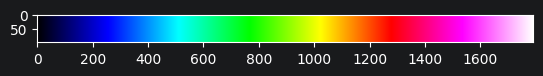

In [4]:
#
# Display image
#
image_from_file = cv2.imread('lab4-rainbow.ppm')
pyplot.imshow(cv2.cvtColor(image_from_file, cv2.COLOR_BGR2RGB))

# Zadanie 3

In [5]:
gradient_row = np.zeros((width, 3), dtype=np.uint8)

gradient_row[0:256, 0] = zero
gradient_row[0:256, 1] = zero
gradient_row[0:256, 2] = vals

gradient_row[256:512, 0] = zero
gradient_row[256:512, 1] = vals
gradient_row[256:512, 2] = full

gradient_row[512:768, 0] = zero
gradient_row[512:768, 1] = full
gradient_row[512:768, 2] = inv_vals

gradient_row[768:1024, 0] = vals
gradient_row[768:1024, 1] = full
gradient_row[768:1024, 2] = zero

gradient_row[1024:1280, 0] = full
gradient_row[1024:1280, 1] = inv_vals
gradient_row[1024:1280, 2] = zero

gradient_row[1280:1536, 0] = full
gradient_row[1280:1536, 1] = zero
gradient_row[1280:1536, 2] = vals

gradient_row[1536:1792, 0] = full
gradient_row[1536:1792, 1] = vals
gradient_row[1536:1792, 2] = full

#
# Image data
#
image = np.tile(gradient_row, (height, 1, 1))

#
# Construct signature
#
png_file_signature = b'\x89PNG\r\n\x1a\n'

#
# Construct header
#
header_id = b'IHDR'
header_content = struct.pack('!IIBBBBB', width, height, 8, 2, 0, 0, 0)
header_size = struct.pack('!I', len(header_content))
header_crc = struct.pack('!I', zlib.crc32(header_id + header_content))
png_file_header = header_size + header_id + header_content + header_crc

#
# Construct data
#
data_id = b'IDAT'
raw_data = b''.join([b'\x00' + bytes(row) for row in image])
data_content = zlib.compress(raw_data)
data_size = struct.pack('!I', len(data_content))
data_crc = struct.pack('!I', zlib.crc32(data_id + data_content))
png_file_data = data_size + data_id + data_content + data_crc

#
# Consruct end
#
end_id = b'IEND'
end_content = b''
end_size = struct.pack('!I', len(end_content))
end_crc = struct.pack('!I', zlib.crc32(end_id + end_content))
png_file_end = end_size + end_id + end_content + end_crc

#
# Save the PNG image as a binary file
#
with open('lab4.png', 'wb') as fh:
    fh.write(png_file_signature)
    fh.write(png_file_header)
    fh.write(png_file_data)
    fh.write(png_file_end)

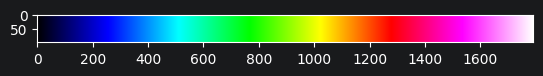

In [6]:
#
# Display image
#
image_from_file = cv2.imread('lab4.png')
pyplot.imshow(cv2.cvtColor(image_from_file, cv2.COLOR_BGR2RGB))

# Funkcje pomocnicze do zadań 4 i 5

In [12]:
#
# 2d Discrete Cosinus Transform
#
def dct2(array):
    return dct(dct(array, axis=0, norm='ortho'), axis=1, norm='ortho')


def idct2(array):
    return idct(idct(array, axis=0, norm='ortho'), axis=1, norm='ortho')


#
# Calculate quantisation matrices
#
# Based on: https://www.hdm-stuttgart.de/~maucher/Python/MMCodecs/html/jpegUpToQuant.html
#           #step-3-and-4-discrete-cosinus-transform-and-quantisation
#
_QY = numpy.array([[16, 11, 10, 16, 24, 40, 51, 61],
                   [12, 12, 14, 19, 26, 48, 60, 55],
                   [14, 13, 16, 24, 40, 57, 69, 56],
                   [14, 17, 22, 29, 51, 87, 80, 62],
                   [18, 22, 37, 56, 68, 109, 103, 77],
                   [24, 35, 55, 64, 81, 104, 113, 92],
                   [49, 64, 78, 87, 103, 121, 120, 101],
                   [72, 92, 95, 98, 112, 100, 103, 99]])

_QC = numpy.array([[17, 18, 24, 47, 99, 99, 99, 99],
                   [18, 21, 26, 66, 99, 99, 99, 99],
                   [24, 26, 56, 99, 99, 99, 99, 99],
                   [47, 66, 99, 99, 99, 99, 99, 99],
                   [99, 99, 99, 99, 99, 99, 99, 99],
                   [99, 99, 99, 99, 99, 99, 99, 99],
                   [99, 99, 99, 99, 99, 99, 99, 99],
                   [99, 99, 99, 99, 99, 99, 99, 99]])


def _scale(QF):
    if QF < 50 and QF >= 1:
        scale = numpy.floor(5000 / QF)
    elif QF < 100:
        scale = 200 - 2 * QF
    else:
        raise ValueError('Quality Factor must be in the range [1..99]')

    scale = scale / 100.0
    return scale


def QY(QF=85):
    return _QY * _scale(QF)


def QC(QF=85):
    return _QC * _scale(QF)

# Zadania 4 i 5

In [13]:
subsample_step = 2

QF = 50
#
# 0. Image data
#
height = 100
width = 7 * 256
gradient_row = np.zeros((width, 3), dtype=np.uint8)
gradient_row[0:256]      = np.column_stack((np.zeros(256), np.zeros(256), np.arange(256)))
gradient_row[256:512]    = np.column_stack((np.zeros(256), np.arange(256), np.full(256, 255)))
gradient_row[512:768]    = np.column_stack((np.zeros(256), np.full(256, 255), np.arange(255, -1, -1)))
gradient_row[768:1024]   = np.column_stack((np.arange(256), np.full(256, 255), np.zeros(256)))
gradient_row[1024:1280]  = np.column_stack((np.full(256, 255), np.arange(255, -1, -1), np.zeros(256)))
gradient_row[1280:1536]  = np.column_stack((np.full(256, 255), np.zeros(256), np.arange(256)))
gradient_row[1536:1792]  = np.column_stack((np.full(256, 255), np.arange(256), np.full(256, 255)))
image = np.tile(gradient_row, (height, 1, 1))

pad_h = (32 - (height % 32)) % 32
pad_w = (32 - (width % 32)) % 32
image_padded = np.pad(image, ((0, pad_h), (0, pad_w), (0, 0)), mode='edge')

#
# 1. Convert RGB to YCbCr
#

xform = np.array([[0.299, 0.587, 0.114],
                  [-0.1687, -0.3313, 0.5],
                  [0.5, -0.4187, -0.0813]])
ycbcr = image_padded.dot(xform.T)
ycbcr[:, :, 1:] += 128

Y  = ycbcr[:, :, 0]
Cb = ycbcr[:, :, 1]
Cr = ycbcr[:, :, 2]


#
# 2. Downsampling on Cb and Cr channels
#
Cb_down = Cb[::subsample_step, ::subsample_step]
Cr_down = Cr[::subsample_step, ::subsample_step]


#
# 3. Produce 8x8 blocks
#
def blockify(channel):
    h, w = channel.shape
    return channel.reshape(h // 8, 8, w // 8, 8).transpose(0, 2, 1, 3)

Y_blocks = blockify(Y)
Cb_blocks = blockify(Cb_down)
Cr_blocks = blockify(Cr_down)
#
# 4. Calculate DCT on each block
#
def apply_to_blocks(blocks, func):
    out = np.empty(blocks.shape, dtype=float)
    for i in range(blocks.shape[0]):
        for j in range(blocks.shape[1]):
            out[i, j] = func(blocks[i, j])
    return out

Y_dct = apply_to_blocks(Y_blocks, dct2)
Cb_dct = apply_to_blocks(Cb_blocks, dct2)
Cr_dct = apply_to_blocks(Cr_blocks, dct2)

#
# 5. Divide each block by quantisation matrix
#
q_y = QY(QF)
q_c = QC(QF)

Y_q = Y_dct / q_y
Cb_q = Cb_dct / q_c
Cr_q = Cr_dct / q_c

#
# 6. Round values in each block to integers
#
Y_blocks = np.round(Y_q)
Cb_blocks = np.round(Cb_q)
Cr_blocks = np.round(Cr_q)

#
# 7. Zig Zag
#
ZIGZAG_ORDER = [
    0, 1, 8, 16, 9, 2, 3, 10,
    17, 24, 32, 25, 18, 11, 4, 5,
    12, 19, 26, 33, 40, 48, 41, 34,
    27, 20, 13, 6, 7, 14, 21, 28,
    35, 42, 49, 56, 57, 50, 43, 36,
    29, 22, 15, 23, 30, 37, 44, 51,
    58, 59, 52, 45, 38, 31, 39, 46,
    53, 60, 61, 54, 47, 55, 62, 63
]

def zigzag(blocks):
    flat_blocks = blocks.reshape(-1, 64)
    return flat_blocks[:, ZIGZAG_ORDER]

Y_zz = zigzag(Y_blocks)
Cb_zz = zigzag(Cb_blocks)
Cr_zz = zigzag(Cr_blocks)

#
# 8. Flatten, concatenate, compress and calculate the size -- how many bytes?
#
data_to_compress = np.concatenate([Y_zz.flatten(), Cb_zz.flatten(), Cr_zz.flatten()]).astype(np.float32)
compressed_data = zlib.compress(data_to_compress.tobytes())
print(f"Rozmiar po kompresji (krok próbkowania = {subsample_step}): {len(compressed_data)} bajtów")

#
# 7'. Undo Zig Zag
#
# We can skip it in this exercise! We did Zig Zag only for analysis in step 8.
# You can continue with result from step 6. instead of implementing undo here.
#

#
# 6'. Nothing to do here   ¯\_(ツ)_/¯
#
# No conversion is really needed here, just proceed to the next step.
#

#
# 5'. Reverse division by quantisation matrix -- multiply
#
Y_deq = Y_blocks * q_y
Cb_deq = Cb_blocks * q_c
Cr_deq = Cr_blocks * q_c

#
# 4'. Reverse DCT
#
Y_blocks = apply_to_blocks(Y_deq, idct2)
Cb_blocks = apply_to_blocks(Cb_deq, idct2)
Cr_blocks = apply_to_blocks(Cr_deq, idct2)

#
# 3'. Combine 8x8 blocks to original image
#
def unblockify(blocks, orig_shape):
    h, w = orig_shape
    return blocks.transpose(0, 2, 1, 3).reshape(h, w)

Y_rec = unblockify(Y_blocks, Y.shape)
Cb_down_rec = unblockify(Cb_blocks, Cb_down.shape)
Cr_down_rec = unblockify(Cr_blocks, Cr_down.shape)


#
# 2'. Upsampling on Cb and Cr channels
#
Cb_rec = np.repeat(np.repeat(Cb_down_rec, subsample_step, axis=0), subsample_step, axis=1)
Cr_rec = np.repeat(np.repeat(Cr_down_rec, subsample_step, axis=0), subsample_step, axis=1)
#
# 1'. Convert YCbCr to RGB
#
ycbcr_rec = np.stack([Y_rec, Cb_rec, Cr_rec], axis=-1)
ycbcr_rec[:, :, 1:] -= 128

inv_xform = np.array([[1, 0, 1.402],
                      [1, -0.34414, -0.71414],
                      [1, 1.772, 0]])
rgb_rec = ycbcr_rec.dot(inv_xform.T)
rgb_rec = np.clip(rgb_rec, 0, 255).astype(np.uint8)

# Przycięcie do oryginalnych rozmiarów (usunięcie paddingu)
final_image = rgb_rec[:height, :width]

#
# 0'. Save the decoded image -- as PPM or PNG
#
Image.fromarray(final_image).save("lab4-po-kompresji-i-dekompresji-jpeg.png")

Rozmiar po kompresji (krok próbkowania = 2): 25097 bajtów


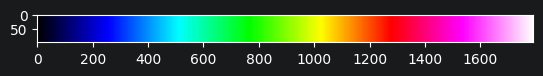

In [14]:
#
# Display image
#
image_from_file = cv2.imread('lab4-po-kompresji-i-dekompresji-jpeg.png')
pyplot.imshow(cv2.cvtColor(image_from_file, cv2.COLOR_BGR2RGB))

# Obserwacje z zadań 4 i 5

In [ ]:
"""Uruchamiając powyższy kod dla różnych wartości zmiennej `subsample_step` zauważamy:

1. Brak próbkowania (subsample_step = 1; tzw. 4:4:4):
   - Najwyższa jakość, obraz wynikowy jest praktycznie nieodróżnialny od oryginału.
   - Rozmiar po kompresji zlib jest największy, ponieważ zapisujemy pełną informację o kolorach (Cr i Cb).

2. Próbkowanie co 2 element (subsample_step = 2; tzw. 4:2:0):
   - Rozmiar danych kompresowanych drastycznie spada. Zmniejszamy ilość danych na kanałach chrominancji aż czterokrotnie (2 razy węższe, 2 razy niższe).
   - Jakość obrazu gołym okiem wciąż pozostaje doskonała, ponieważ ludzkie oko jest mniej wrażliwe na rozdzielczość kolorów niż na jasność (luminancję Y).

3. Próbkowanie co 4 element (subsample_step = 4):
   - Rozmiar spada jeszcze bardziej, uzyskując maksymalny stopień redukcji bajtów w tym etapie.
   - Pojawiają się jednak pierwsze widoczne artefakty - ostre krawędzie pomiędzy skrajnymi kolorami tęczy zaczynają się rozmywać i pikselować na granicach, tracąc "ostrość" gradientu (ang. color bleeding).


   Zmiana wartości QF w kroku 5 pozwala nam płynnie regulować kompromis między
wielkością pliku a jakością obrazu. Na podstawie testów można wyciągnąć następujące wnioski:

4. Niski QF (np. QF = 10):
   - Rozmiar: Radykalnie się zmniejsza. Wartości w macierzach kwantyzacji QY i QC stają się
     bardzo duże. Dzielenie przez nie (i zaokrąglanie w kroku 6) sprawia, że większość
     współczynników DCT wysokich częstotliwości staje się absolutnymi zerami. Kompresja
     zlib osiąga wtedy znakomite rezultaty.
   - Wygląd: Jakość obrazu drastycznie spada. Widoczne stają się bardzo wyraźne artefakty
     blokowe (charakterystyczne "kwadraty" 8x8), ponieważ tracimy informacje o łagodnych
     przejściach i detalach wewnątrz każdego z bloków.

5. Wysoki QF (np. QF = 90):
   - Rozmiar: Rośnie. Dzielniki w macierzach kwantyzacji są małe, przez co zachowujemy
     więcej niezerowych wartości po zaokrągleniu. Obraz słabiej się kompresuje.
   - Wygląd: Jakość zrekonstruowanego obrazka jest bardzo wysoka, rzadko kiedy można
     zauważyć gołym okiem różnicę względem oryginału.
"""